# Individual Assignment 1  Due Date Dec 9, 9 am
# Case Study 1 — Individual Rework (Machine Learning Comparison)
# Pilgrim Bank Case Study (Part A)

Pilgrim Bank is debating whether to invest in a targeted campaign that encourages customers to adopt online banking.
Working with the 1999 customer dataset from the case packet, we examine how profit varies across online and offline
users while accounting for demographic and relationship factors highlighted in the brief. We follow the analytic steps
to build quantitative evidence that informs Pilgrim Bank's marketing decision.

# To Do Now:
Objective: The objective of this Case Study is to extend Case Study 1 by implementing and evaluating nonlinear ML models instead of linear regression. Compare performance, discuss findings, and reflect on whether these models improve on the original baseline.
Models to implement (at minimum): 
# Models:
A. Decision Tree
B. Random Forest
C. Support Vector Machine (SVM)
D. XGBoost
# In this Notebook(.ipynb) I aim to do the following:
1. Prepares data (renaming, missingness flags, imputation, scaling, one-hot encoding).

2. Trains and tunes Decision Tree, Random Forest, SVR, XGBoost via GridSearchCV.

3. Evaluates each model and compares against the linear regression baseline.

4. Provides feature importance plots (RF + XGBoost) and a learning curve for XGBoost that you can discuss in terms of bias–variance and nonlinearity.


In [1]:
# Install required packages
%pip install pandas numpy matplotlib seaborn scikit-learn statsmodels --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Import required libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
 
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    learning_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 2025
np.random.seed(RANDOM_STATE)

# Configure global plotting and display behaviour for readability.
sns.set_theme(style="whitegrid", context="talk")

# Define constants
#RANDOM_STATE = 2025
DATA_PATH = "PilgrimDataA.csv"

# =========================================
# 1. Load data & basic cleaning
# =========================================

In [ ]:
# Define some helper functions for reporting.


df_raw = pd.read_csv("PilgrimDataA.csv")

print("Original columns:", df_raw.columns.tolist())

# Rename columns to something readable (adapt if your file differs)
rename_map = {
    "9Profit": "profit_1999",
    "0Profit": "profit_2000",
    "9Online": "online_1999",
    "0Online": "online_2000",
    "9Age": "age_1999",
    "9Inc": "income_1999",
    "9Tenure": "tenure",
    "9District": "district",
    "9Billpay": "billpay_1999",
    "0Billpay": "billpay_2000",
}
df = df_raw.rename(columns=rename_map).copy()

# Keep only the columns we will use (you can add more if you want)
cols_of_interest = [
    "profit_1999",
    "online_1999",
    "age_1999",
    "income_1999",
    "tenure",
    "district",
    "billpay_1999",
]
df = df[cols_of_interest]
df.head(6)
print("\nData info after selecting columns:")
print(df.info())
print("\nBasic stats:")
print(df.describe(include="all"))

Original columns: ['ID', '9Profit', '9Online', '9Age', '9Inc', '9Tenure', '9District', '0Profit', '0Online', '9Billpay', '0Billpay']

Data info after selecting columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31634 entries, 0 to 31633
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   profit_1999   31634 non-null  int64  
 1   online_1999   31634 non-null  int64  
 2   age_1999      23345 non-null  float64
 3   income_1999   23373 non-null  float64
 4   tenure        31634 non-null  float64
 5   district      31634 non-null  int64  
 6   billpay_1999  31634 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 1.7 MB
None

Basic stats:
        profit_1999   online_1999      age_1999   income_1999        tenure  \
count  31634.000000  31634.000000  23345.000000  23373.000000  31634.000000   
mean     111.502687      0.121831      4.046048      5.458777     10.162690   
std      272.839391      0.327

# =========================================
# 2. Data preparation & feature engineering
# =========================================

In [9]:
# ---- 2.1: Create missingness indicators ----
df["age_exists"] = df["age_1999"].notna().astype(int)
df["income_exists"] = df["income_1999"].notna().astype(int)

# ---- 2.2: Target & features ----
target_col = "profit_1999"

# Numeric features (to be imputed + scaled)
numeric_features = [
    "age_1999",
    "income_1999",
    "tenure",
    "billpay_1999",
    "online_1999",
    "age_exists",
    "income_exists",
]

# Categorical features (to be imputed + one-hot encoded)
categorical_features = ["district"]

In [8]:
# Drop rows with missing target
df = df.dropna(subset=[target_col]).copy()

X = df[numeric_features + categorical_features]
y = df[target_col]

# ---- 2.3: Preprocessing pipelines ----
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# ---- 2.4: Train / test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (25307, 8) Test shape: (6327, 8)


# 3. Helper: evaluation function

In [12]:
# =========================================
# 3. Helper: evaluation function
# =========================================

def regression_metrics(y_true, y_pred, label="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    print(f"{label} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R^2: {r2:.3f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# =========================================
# 4. Baseline: Linear Regression with same preprocessing
# =========================================

In [14]:
# Define ppipeline for baseline model: Linear Regression 
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define helper function for regression metrics
def regression_metrics(y_true, y_pred, label="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label} -> RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")
    return {"RMSE": rmse, "MAE": mae, "R2": r2}

# Define pipeline for baseline model: Linear Regression
baseline_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),   # must be defined earlier
        ("regressor", LinearRegression()),
    ]
)

# Fit baseline model
baseline_pipe.fit(X_train, y_train)

# Predictions
y_train_pred_base = baseline_pipe.predict(X_train)
y_test_pred_base = baseline_pipe.predict(X_test)

# Evaluate
print("\n=== Baseline: Linear Regression ===")
baseline_train_metrics = regression_metrics(y_train, y_train_pred_base, "Baseline (train)")
baseline_test_metrics = regression_metrics(y_test, y_test_pred_base, "Baseline (test)")



=== Baseline: Linear Regression ===
Baseline (train) -> RMSE: 264.558, MAE: 172.067, R²: 0.063
Baseline (test) -> RMSE: 261.912, MAE: 170.231, R²: 0.067


# =========================================
# 5. Nonlinear models: Decision Tree, Random Forest, SVR, XGBoost
#    with GridSearchCV
# =========================================


In [15]:
results = []

# Common CV strategy
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = "neg_root_mean_squared_error"  # for regression

# ---- 5.1 Decision Tree ----

In [ ]:
# ---- Define pipeline for Decision Tree ----
dt_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ]
)

dt_param_grid = {
    "regressor__max_depth": [3, 5, 10, None],
    "regressor__min_samples_split": [2, 20, 50],
    "regressor__min_samples_leaf": [1, 5, 20],
}

dt_grid = GridSearchCV(
    dt_pipe,
    dt_param_grid,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

print("\nFitting Decision Tree...")
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_

print("Best DT params:", dt_grid.best_params_)

y_train_pred_dt = dt_best.predict(X_train)
y_test_pred_dt = dt_best.predict(X_test)

dt_train_metrics = regression_metrics(y_train, y_train_pred_dt, "Decision Tree (train)")
dt_test_metrics = regression_metrics(y_test, y_test_pred_dt, "Decision Tree (test)")

results.append(
    {
        "Model": "Decision Tree",
        "Train_RMSE": dt_train_metrics["RMSE"],
        "Test_RMSE": dt_test_metrics["RMSE"],
        "Train_R2": dt_train_metrics["R2"],
        "Test_R2": dt_test_metrics["R2"],
    }
)



Fitting Decision Tree...
Best DT params: {'regressor__max_depth': 5, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 20}
Decision Tree (train) -> RMSE: 263.028, MAE: 170.967, R²: 0.073
Decision Tree (test) -> RMSE: 262.369, MAE: 170.921, R²: 0.064


# Visualize the Decision Tree

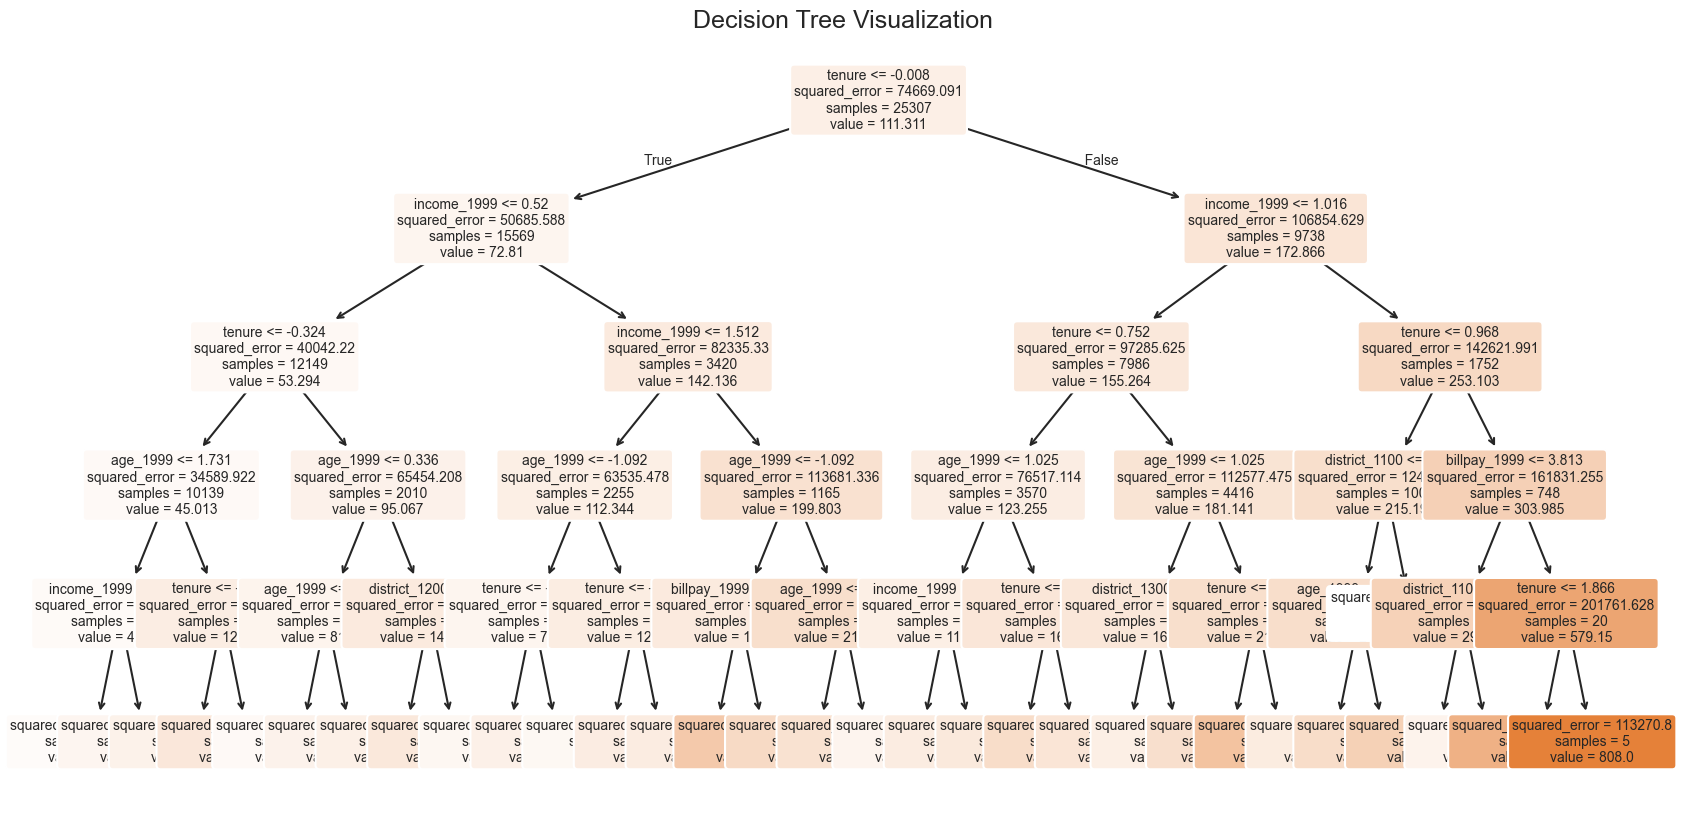

In [20]:
# ---- Visualize the Decision Tree ----
# Extract the fitted regressor from the pipeline
dt_model = dt_best.named_steps["regressor"]

# Ensure tree plotting helper is available
from sklearn import tree

# Get feature names after preprocessing
# Use the original categorical feature names when calling get_feature_names_out.
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
# Use named_transformers_ to check presence (transformers_ contains 3-tuples and can't be cast to dict)
cat_feature_names = ohe.get_feature_names_out(categorical_features) if "cat" in preprocessor.named_transformers_ else []
num_feature_names = numeric_features if "num" in preprocessor.named_transformers_ else []
# ColumnTransformer was defined with numeric features first, then categorical features,
# so keep the same order for feature names.
feature_names = list(num_feature_names) + list(cat_feature_names)

plt.figure(figsize=(20,10))
tree.plot_tree(
    dt_model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization")
plt.show()


# Feature Importance Bar Plot


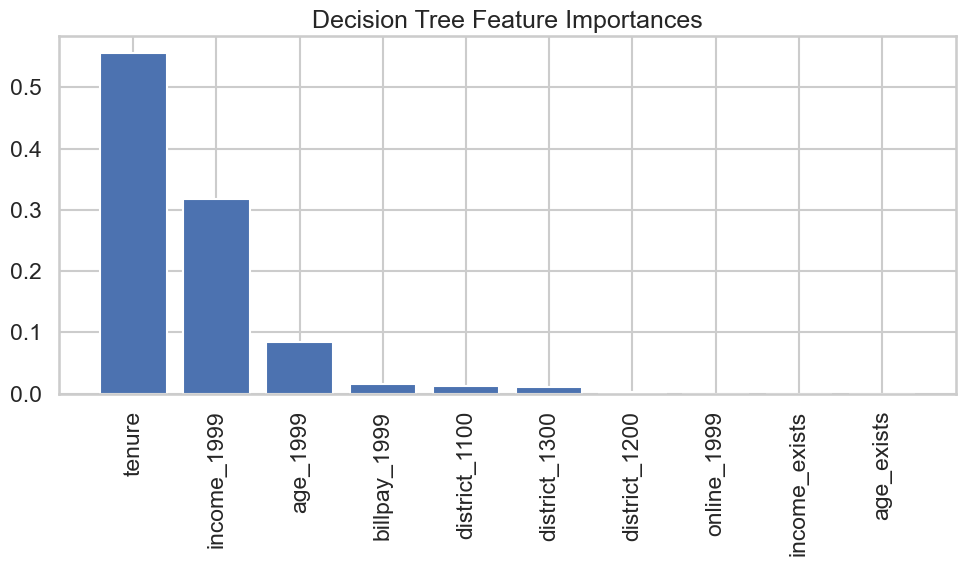

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Feature importances from the fitted tree
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.title("Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

# ---- 5.2 Random Forest ----

In [21]:
# ---- Define pipeline for Random Forest ----
rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ]
)

rf_param_grid = {
    "regressor__n_estimators": [100, 300],
    "regressor__max_depth": [None, 10, 20],
    "regressor__min_samples_split": [2, 20],
    "regressor__min_samples_leaf": [1, 5],
}

rf_grid = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

print("\nFitting Random Forest...")
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

print("Best RF params:", rf_grid.best_params_)

y_train_pred_rf = rf_best.predict(X_train)
y_test_pred_rf = rf_best.predict(X_test)

rf_train_metrics = regression_metrics(y_train, y_train_pred_rf, "Random Forest (train)")
rf_test_metrics = regression_metrics(y_test, y_test_pred_rf, "Random Forest (test)")

results.append(
    {
        "Model": "Random Forest",
        "Train_RMSE": rf_train_metrics["RMSE"],
        "Test_RMSE": rf_test_metrics["RMSE"],
        "Train_R2": rf_train_metrics["R2"],
        "Test_R2": rf_test_metrics["R2"],
    }
)


Fitting Random Forest...
Best RF params: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 20, 'regressor__n_estimators': 300}
Random Forest (train) -> RMSE: 252.763, MAE: 164.190, R²: 0.144
Random Forest (test) -> RMSE: 262.241, MAE: 170.743, R²: 0.065


# Visualization for Random Forest

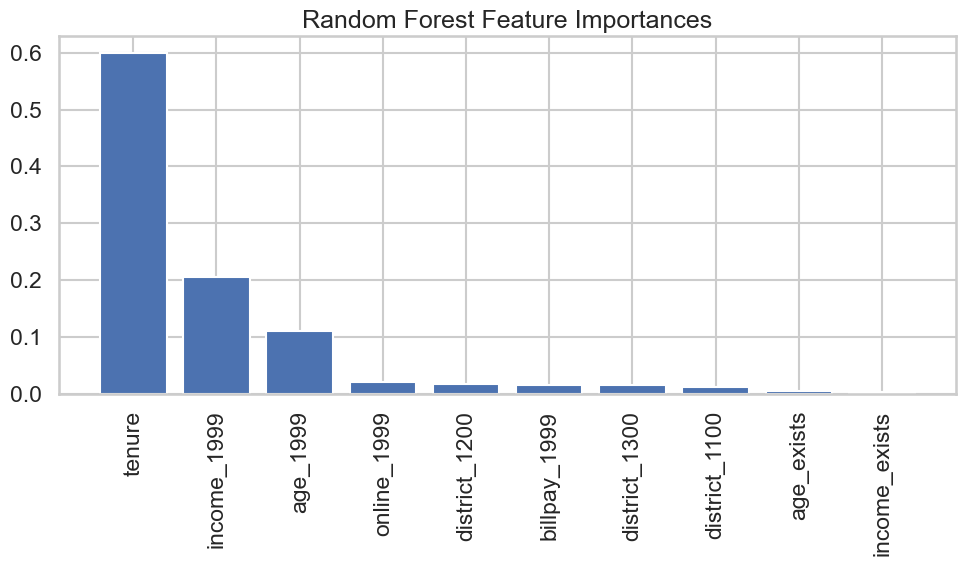

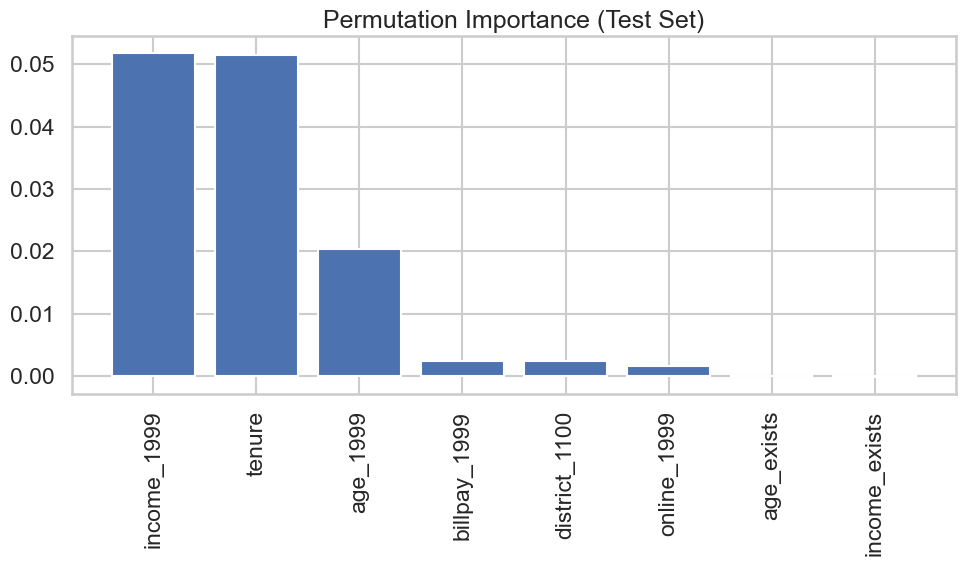

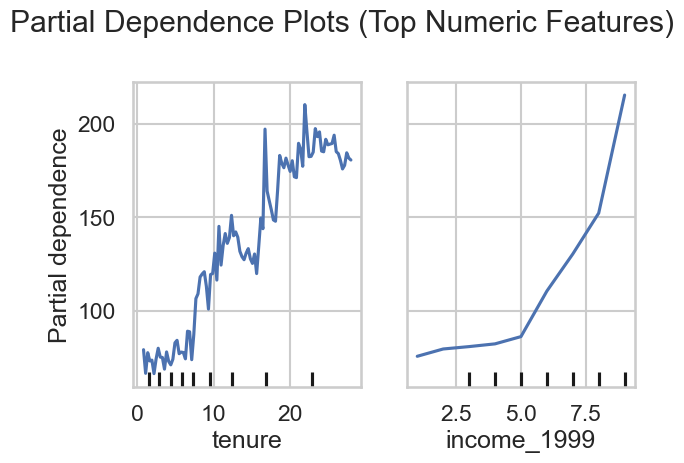

In [23]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# ---- Visualization for Random Forest ----
# Extract the trained regressor from the pipeline
rf_model = rf_best.named_steps["regressor"]

# Get feature names after preprocessing.
# The ColumnTransformer was defined with numeric features first, then categorical.
# So build feature names in that same order: numeric_features + one-hot encoded cat names.
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
num_feature_names = numeric_features
feature_names = list(num_feature_names) + list(cat_feature_names)

# 1. Feature Importance (built-in)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# 2. Permutation Importance (more robust) - use the test set (X_test, y_test)
perm = permutation_importance(
    rf_best, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
sorted_idx = perm.importances_mean.argsort()[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(sorted_idx)), perm.importances_mean[sorted_idx], align="center")
plt.xticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx], rotation=90)
plt.title("Permutation Importance (Test Set)")
plt.tight_layout()
plt.show()

# 3. Partial Dependence Plot (for top original features)
# Map top transformed-feature indices back to original numeric features when possible.
# Prefer showing PDPs for original numeric variables (they are the first len(num_feature_names) entries).
top_transformed = indices  # already sorted by importance
top_numeric_indices = [i for i in top_transformed if i < len(num_feature_names)]
top_original_names = [num_feature_names[i] for i in top_numeric_indices][:2]

# Fallback: if no numeric features in top list, pick first two numeric features
if len(top_original_names) == 0:
    top_original_names = num_feature_names[:2]

PartialDependenceDisplay.from_estimator(rf_best, X_test, top_original_names, kind="average")
plt.suptitle("Partial Dependence Plots (Top Numeric Features)")
plt.tight_layout()
plt.show()

# ---- 5.3 Support Vector Machine (SVM) ----

In [24]:
# ---- Define Pipeline for Support Vector Machine (SVM) ----
svr_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", SVR()),
    ]
)

svr_param_grid = {
    "regressor__kernel": ["rbf"],
    "regressor__C": [1.0, 10.0, 100.0],
    "regressor__gamma": ["scale", 0.1, 0.01],
    "regressor__epsilon": [0.1, 1.0],
}

svr_grid = GridSearchCV(
    svr_pipe,
    svr_param_grid,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

print("\nFitting SVR...")
svr_grid.fit(X_train, y_train)
svr_best = svr_grid.best_estimator_

print("Best SVR params:", svr_grid.best_params_)

y_train_pred_svr = svr_best.predict(X_train)
y_test_pred_svr = svr_best.predict(X_test)

svr_train_metrics = regression_metrics(y_train, y_train_pred_svr, "SVR (train)")
svr_test_metrics = regression_metrics(y_test, y_test_pred_svr, "SVR (test)")

results.append(
    {
        "Model": "SVR",
        "Train_RMSE": svr_train_metrics["RMSE"],
        "Test_RMSE": svr_test_metrics["RMSE"],
        "Train_R2": svr_train_metrics["R2"],
        "Test_R2": svr_test_metrics["R2"],
    }
)


Fitting SVR...
Best SVR params: {'regressor__C': 100.0, 'regressor__epsilon': 0.1, 'regressor__gamma': 'scale', 'regressor__kernel': 'rbf'}
SVR (train) -> RMSE: 276.685, MAE: 153.321, R²: -0.025
SVR (test) -> RMSE: 275.990, MAE: 153.823, R²: -0.036


#  Visualization for SVM

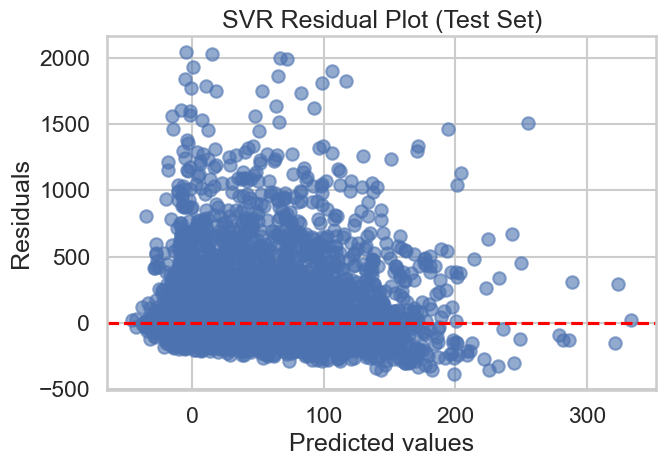

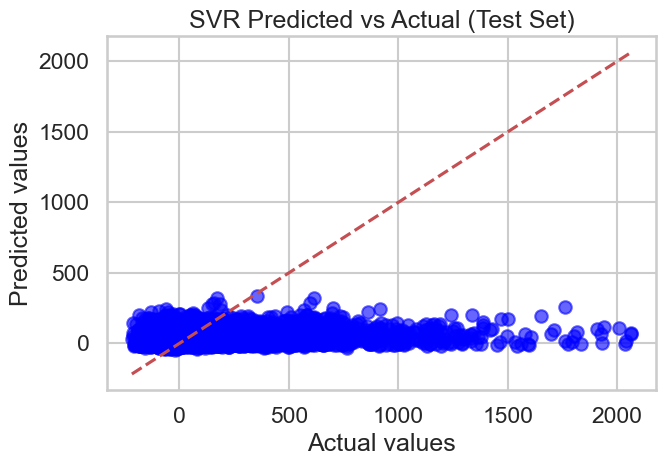

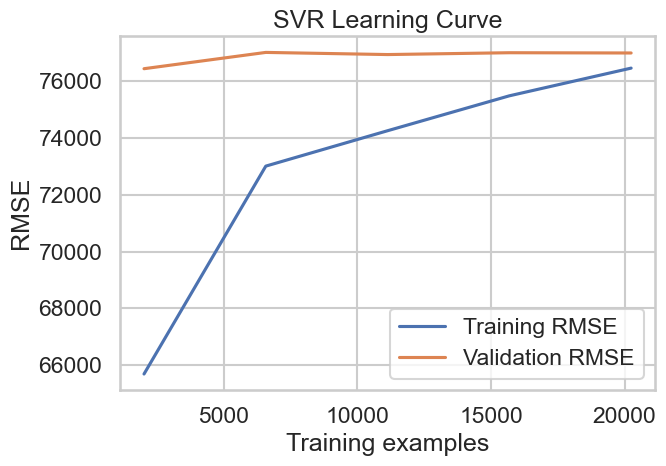

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

# ---- Visualization for SVR ----

# 1. Residual plot (Test set)
residuals = y_test - y_test_pred_svr
plt.figure(figsize=(7,5))
plt.scatter(y_test_pred_svr, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("SVR Residual Plot (Test Set)")
plt.tight_layout()
plt.show()

# 2. Predicted vs Actual scatterplot
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_test_pred_svr, alpha=0.6, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")  # 45° line
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("SVR Predicted vs Actual (Test Set)")
plt.tight_layout()
plt.show()

# 3. Learning curve (Train vs Validation)
train_sizes, train_scores, val_scores = learning_curve(
    svr_best, X_train, y_train,
    cv=cv, scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, -train_scores.mean(axis=1), label="Training RMSE")
plt.plot(train_sizes, -val_scores.mean(axis=1), label="Validation RMSE")
plt.xlabel("Training examples")
plt.ylabel("RMSE")
plt.title("SVR Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()


# --- 5.4 XGBoost Regressor ----

In [26]:
# ----Define Pipeline for XGBoost Regressor ----
xgb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            XGBRegressor(
                objective="reg:squarederror",
                eval_metric="rmse",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

xgb_param_grid = {
    "regressor__n_estimators": [200, 400],
    "regressor__max_depth": [3, 5, 8],
    "regressor__learning_rate": [0.05, 0.1],
    "regressor__subsample": [0.8, 1.0],
    "regressor__colsample_bytree": [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    xgb_pipe,
    xgb_param_grid,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

print("\nFitting XGBoost...")
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_

print("Best XGB params:", xgb_grid.best_params_)

y_train_pred_xgb = xgb_best.predict(X_train)
y_test_pred_xgb = xgb_best.predict(X_test)

xgb_train_metrics = regression_metrics(y_train, y_train_pred_xgb, "XGBoost (train)")
xgb_test_metrics = regression_metrics(y_test, y_test_pred_xgb, "XGBoost (test)")

results.append(
    {
        "Model": "XGBoost",
        "Train_RMSE": xgb_train_metrics["RMSE"],
        "Test_RMSE": xgb_test_metrics["RMSE"],
        "Train_R2": xgb_train_metrics["R2"],
        "Test_R2": xgb_test_metrics["R2"],
    }
)



Fitting XGBoost...
Best XGB params: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 200, 'regressor__subsample': 1.0}
XGBoost (train) -> RMSE: 261.607, MAE: 169.839, R²: 0.083
XGBoost (test) -> RMSE: 260.879, MAE: 169.581, R²: 0.074


# XGBoost Visuals

<Figure size 1000x600 with 0 Axes>

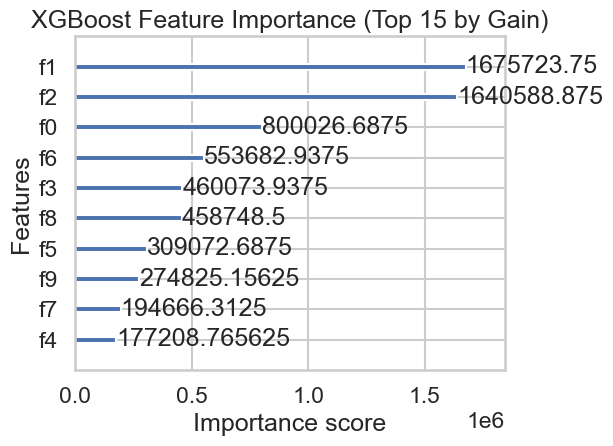

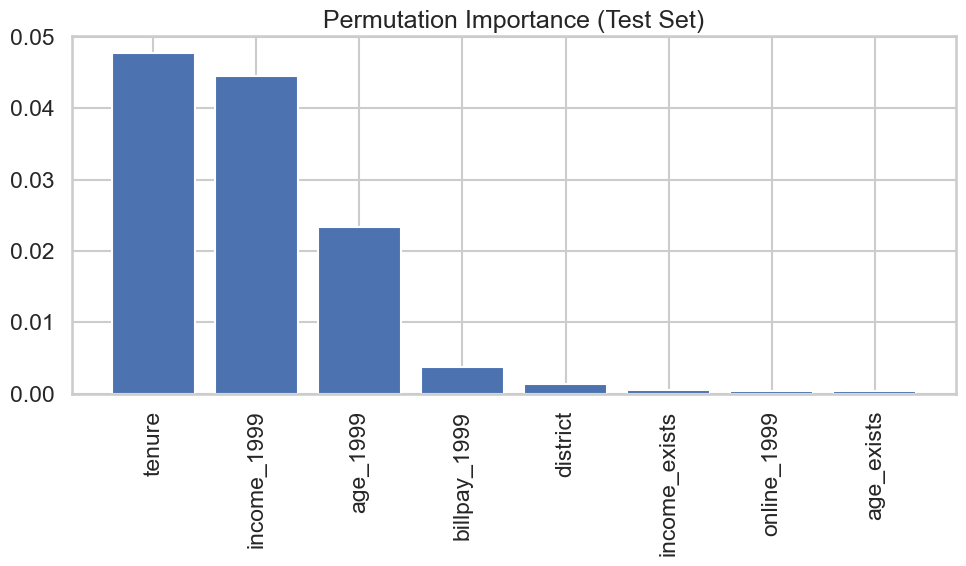

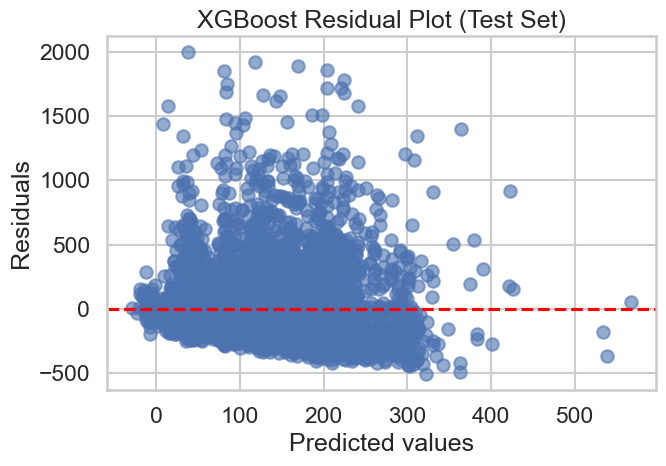

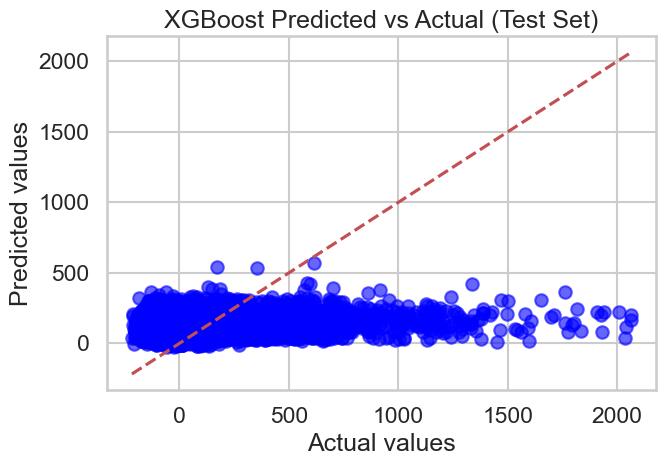

In [29]:
from xgboost import plot_importance

# ---- Visualization for XGBoost ----

# Extract the trained regressor from the pipeline
xgb_model = xgb_best.named_steps["regressor"]

# Feature names corresponding to the original input columns used by the pipeline.
# permutation_importance when applied to a Pipeline returns importances per original input feature,
# so use numeric_features + categorical_features (not one-hot expanded names).
feature_names = numeric_features + categorical_features

# 1. Built-in XGBoost Feature Importance
plt.figure(figsize=(10,6))
plot_importance(xgb_model, max_num_features=15, importance_type="gain")
plt.title("XGBoost Feature Importance (Top 15 by Gain)")
plt.tight_layout()
plt.show()

# 2. Permutation Importance (Test set)
# Use the test set (X_test, y_test) which exist in the notebook.
perm = permutation_importance(xgb_best, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
sorted_idx = perm.importances_mean.argsort()[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(sorted_idx)), perm.importances_mean[sorted_idx], align="center")
plt.xticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx], rotation=90)
plt.title("Permutation Importance (Test Set)")
plt.tight_layout()
plt.show()

# 3. Residual Plot (Test set)
residuals = y_test - y_test_pred_xgb
plt.figure(figsize=(7,5))
plt.scatter(y_test_pred_xgb, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("XGBoost Residual Plot (Test Set)")
plt.tight_layout()
plt.show()

# 4. Predicted vs Actual Scatterplot
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_test_pred_xgb, alpha=0.6, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")  # 45° line
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("XGBoost Predicted vs Actual (Test Set)")
plt.tight_layout()
plt.show()

# Add baseline to results

In [30]:
# Add baseline to results
results.append(
    {
        "Model": "Linear Regression (baseline)",
        "Train_RMSE": baseline_train_metrics["RMSE"],
        "Test_RMSE": baseline_test_metrics["RMSE"],
        "Train_R2": baseline_train_metrics["R2"],
        "Test_R2": baseline_test_metrics["R2"],
    }
)

# =========================================
# 6. Model comparison table & barplot
# ======


=== Model comparison (lower RMSE better, higher R^2 better) ===
                          Model  Train_RMSE   Test_RMSE  Train_R2   Test_R2
3                       XGBoost  261.606620  260.879238  0.083449  0.074266
4  Linear Regression (baseline)  264.558435  261.911608  0.062649  0.066925
1                 Random Forest  252.763244  262.240779  0.144368  0.064578
0                 Decision Tree  263.027914  262.369273  0.073463  0.063661
2                           SVR  276.685495  275.990124 -0.025255 -0.036083


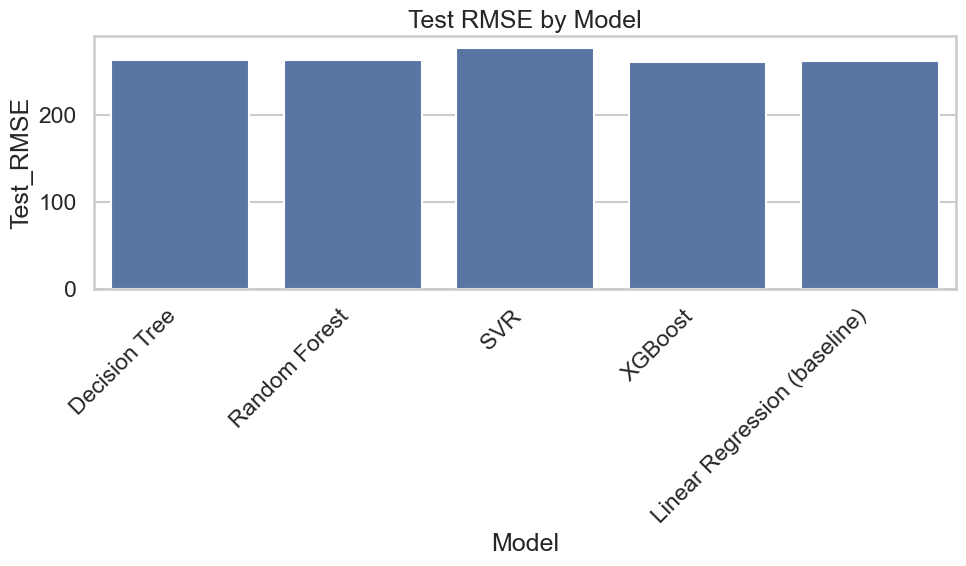

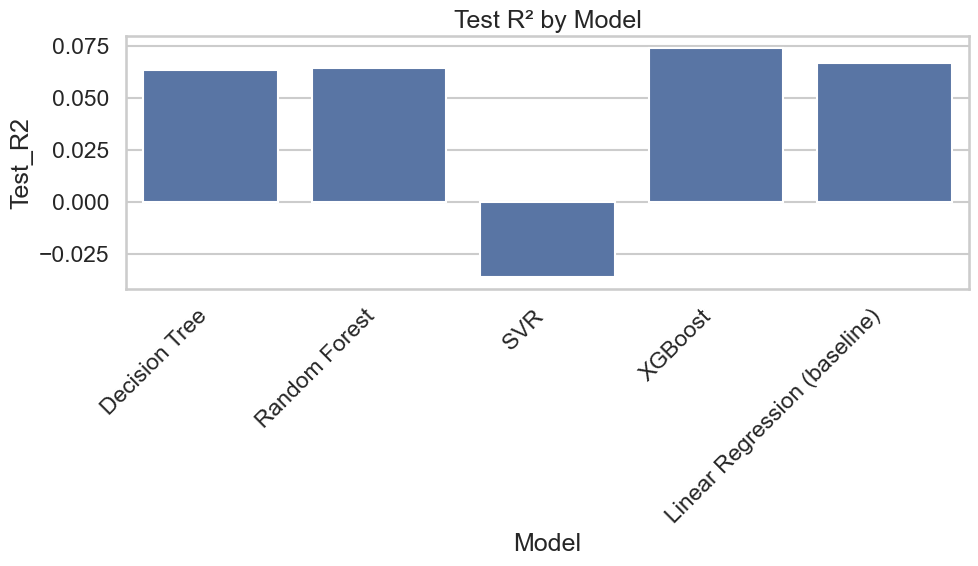

In [31]:
# =========================================
# 6. Model comparison table & barplot
# ==========================================
results_df = pd.DataFrame(results)
print("\n=== Model comparison (lower RMSE better, higher R^2 better) ===")
print(results_df.sort_values("Test_RMSE"))

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="Test_RMSE")
plt.xticks(rotation=45, ha="right")
plt.title("Test RMSE by Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="Test_R2")
plt.xticks(rotation=45, ha="right")
plt.title("Test R² by Model")
plt.tight_layout()
plt.show()


# 7. Interpretation: feature importance for a top models: Random Forest and XGBoost

In [32]:
# =========================================
# 7. Interpretation: feature importance for a top model: Random Forest and XGBoost
# =========================================

def get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features):
    """
    Extract the final feature names after ColumnTransformer.
    """
    feature_names = []

    # numeric part
    num_transformer = preprocessor.named_transformers_["num"]
    # after imputer + scaler, numeric names stay the same
    feature_names.extend(numeric_features)

    # categorical part
    cat_transformer = preprocessor.named_transformers_["cat"]
    ohe = cat_transformer.named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(categorical_features).tolist()
    feature_names.extend(cat_names)

    return feature_names


# 7.1. Feature Importance for Random Forest


=== Random Forest feature importance ===
         feature  importance
2         tenure    0.599328
1    income_1999    0.204450
0       age_1999    0.110599
4    online_1999    0.019594
8  district_1200    0.016593
3   billpay_1999    0.015724
9  district_1300    0.014447
7  district_1100    0.012061
5     age_exists    0.004579
6  income_exists    0.002625


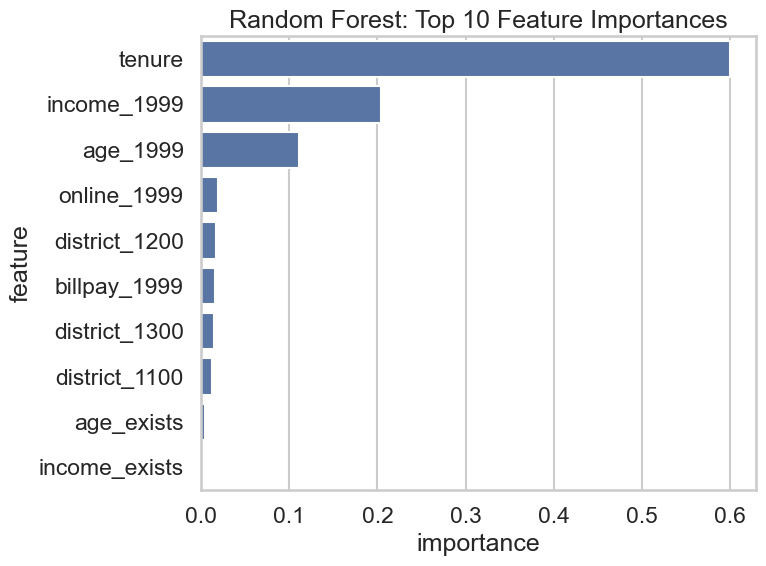

In [41]:
# ---- 7.1 Feature importance for Random Forest ----
rf_preprocessor = rf_best.named_steps["preprocessor"]
rf_regressor = rf_best.named_steps["regressor"]

feature_names = get_feature_names_from_preprocessor(
    rf_preprocessor, numeric_features, categorical_features
)

rf_importances = rf_regressor.feature_importances_

fi_rf = (
    pd.DataFrame({"feature": feature_names, "importance": rf_importances})
    .sort_values("importance", ascending=False)
)

print("\n=== Random Forest feature importance ===")
print(fi_rf.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(
    data=fi_rf.head(15),
    x="importance",
    y="feature",
)
plt.title("Random Forest: Top 10 Feature Importances")
plt.tight_layout()
plt.show()


# 7.2 Feature importance for XGBoost (optional)


=== XGBoost feature importance ===
         feature  importance
1    income_1999    0.256046
2         tenure    0.250678
0       age_1999    0.122242
6  income_exists    0.084601
3   billpay_1999    0.070298
8  district_1200    0.070096
5     age_exists    0.047225
9  district_1300    0.041993
7  district_1100    0.029744
4    online_1999    0.027077


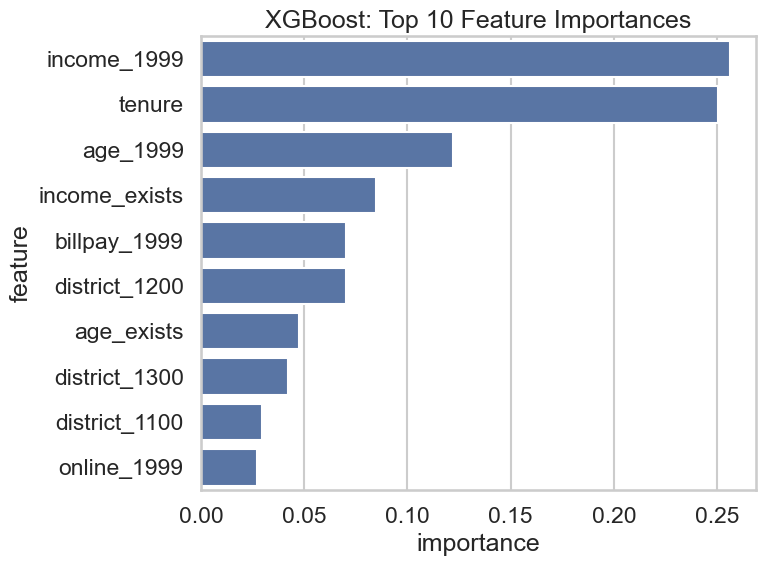

In [42]:
# ---- 7.2 Feature importance for XGBoost (optional) ----
xgb_preprocessor = xgb_best.named_steps["preprocessor"]
xgb_regressor = xgb_best.named_steps["regressor"]

xgb_feature_names = get_feature_names_from_preprocessor(
    xgb_preprocessor, numeric_features, categorical_features
)

xgb_importances = xgb_regressor.feature_importances_

fi_xgb = (
    pd.DataFrame({"feature": xgb_feature_names, "importance": xgb_importances})
    .sort_values("importance", ascending=False)
)

print("\n=== XGBoost feature importance ===")
print(fi_xgb.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(
    data=fi_xgb.head(15),
    x="importance",
    y="feature",
)
plt.title("XGBoost: Top 10 Feature Importances")
plt.tight_layout()
plt.show()


# =========================================
# 8.  Learning curve for the best model (example: XGBoost)
# =========================================

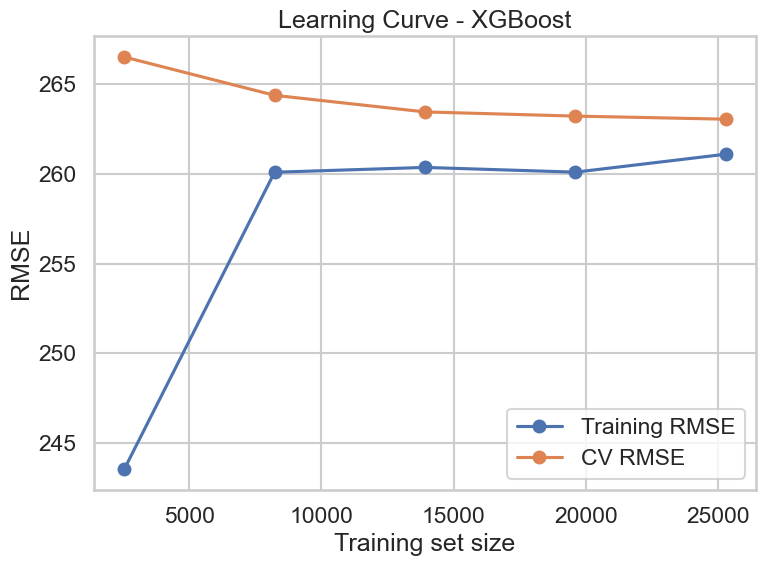

In [36]:
# Learning curve for the best model (example: XGBoost)
# =========================================

train_sizes, train_scores, test_scores = learning_curve(
    xgb_best,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
)

train_rmse = -np.mean(train_scores, axis=1)
test_rmse = -np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_rmse, marker="o", label="Training RMSE")
plt.plot(train_sizes, test_rmse, marker="o", label="CV RMSE")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Learning Curve - XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

#  AUC and ROC Curve for XGBoost Classifier

Fitting XGBoost classifier for ROC/AUC...


d:\MMA 602\Sessions-tutorial\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:02:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


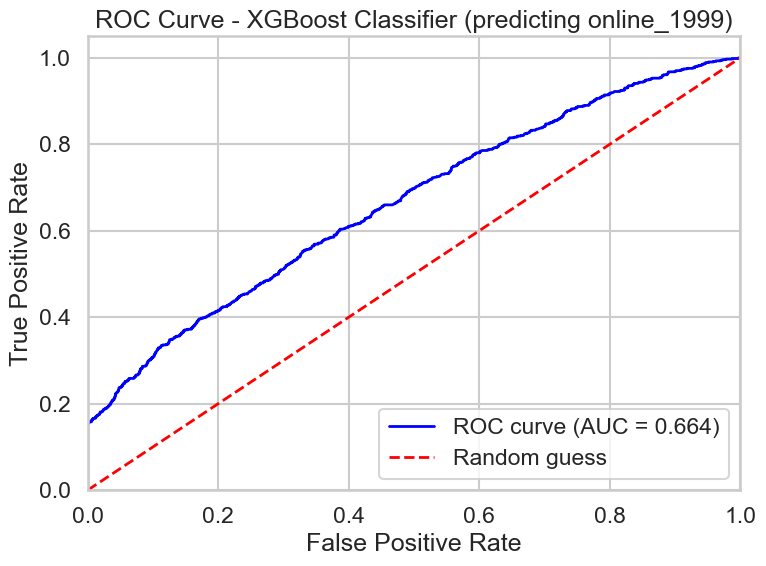

In [40]:
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Fit XGBoost classifier pipeline
print("Fitting XGBoost classifier for ROC/AUC...")
clf_pipe.fit(X_clf_train, y_clf_train)

# Predicted probabilities for positive class
y_test_proba = clf_pipe.predict_proba(X_clf_test)[:, 1]

# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_clf_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color="red", lw=2, linestyle="--", label="Random guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost Classifier (predicting online_1999)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Conclusions and Recommendations